# Data Visualization: Students Performance

## Описание датасета
Используется датасет **StudentsPerformance** с информацией о результатах школьников:
пол, группа, уровень образования родителей, тип питания, прохождение подготовительного курса и баллы по трём предметам.

## Зачем строить графики
Визуализация помогает:
- увидеть распределения признаков;
- сравнить группы между собой;
- заметить возможные зависимости между предметами;
- быстрее сформулировать гипотезы для дальнейшего анализа.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set(style="whitegrid", rc={"figure.figsize": (9, 6)})

sp = pd.read_csv("https://stepik.org/media/attachments/course/4852/StudentsPerformance.csv")
sp = sp.rename(columns={
    "parental level of education": "parental_level_of_education",
    "test preparation course": "test_preparation_course",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score",
    "race/ethnicity": "race_ethnicity",
})
sp.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1. Распределение баллов по математике
Гистограмма показывает, как часто встречаются разные значения `math_score`.

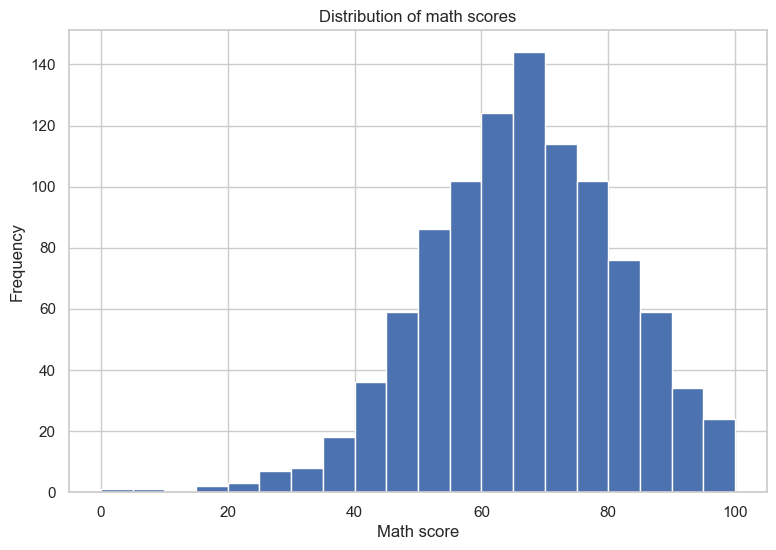

In [3]:
sp["math_score"].hist(bins=20)
plt.xlabel("Math score")
plt.ylabel("Frequency")
plt.title("Distribution of math scores")
plt.show()

## 2. Сравнение распределений по предметам
Посмотрим, как распределены результаты по трём экзаменам.

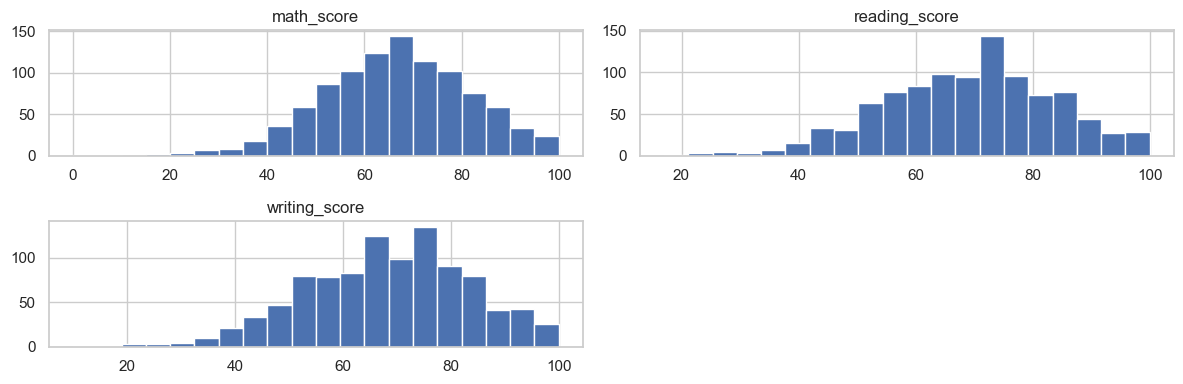

In [4]:
sp[["math_score", "reading_score", "writing_score"]].hist(figsize=(12, 4), bins=20)
plt.tight_layout()
plt.show()

## 3. Связь между математикой и чтением
Диаграмма рассеяния помогает увидеть, идут ли высокие результаты по двум предметам вместе.

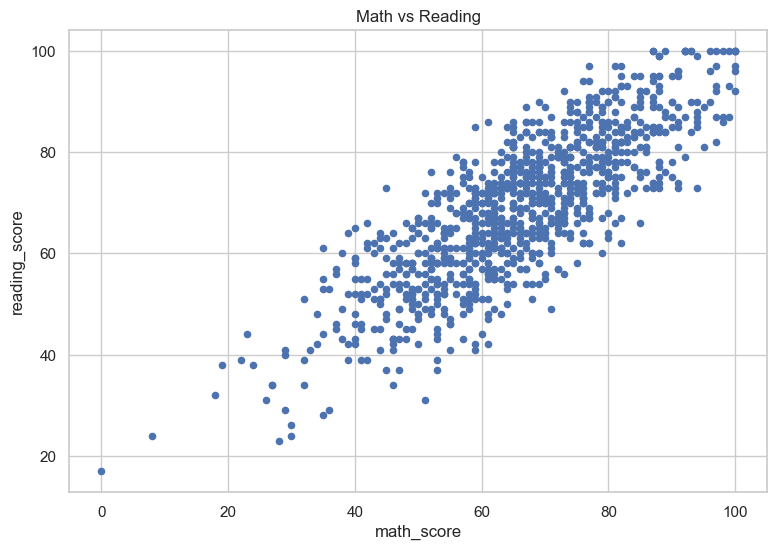

In [5]:
sp.plot.scatter(x="math_score", y="reading_score")
plt.title("Math vs Reading")
plt.show()

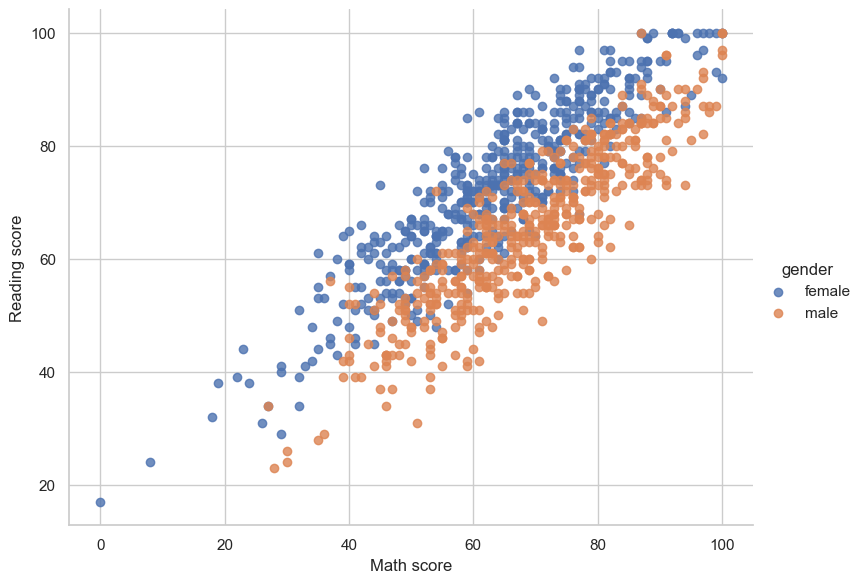

In [6]:
ax = sns.lmplot(
    x="math_score",
    y="reading_score",
    hue="gender",
    data=sp,
    fit_reg=False,
    height=6,
    aspect=1.3
)
ax.set_xlabels("Math score")
ax.set_ylabels("Reading score")
plt.show()

## 4. Сравнение групп по полу
Boxplot хорошо показывает медиану, разброс и возможные выбросы.

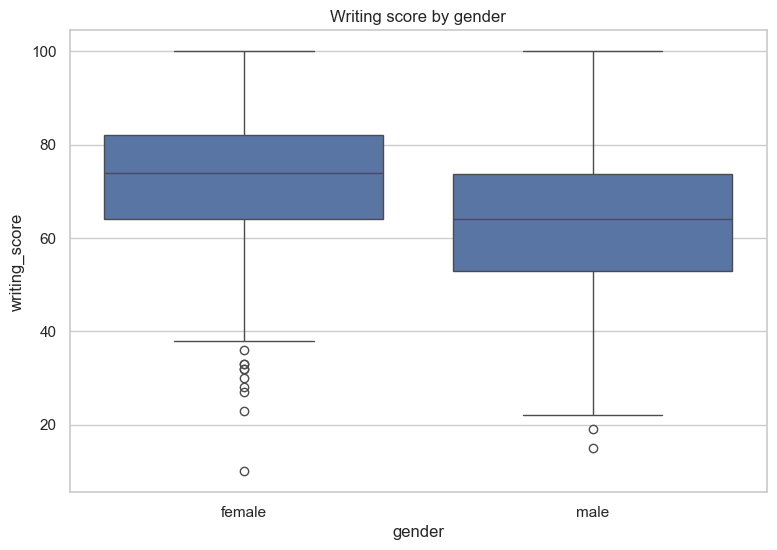

In [7]:
sns.boxplot(data=sp, x="gender", y="writing_score")
plt.title("Writing score by gender")
plt.show()

## 5. Влияние подготовительного курса
Сравниваю результаты по математике между учащимися, которые проходили и не проходили курс подготовки.

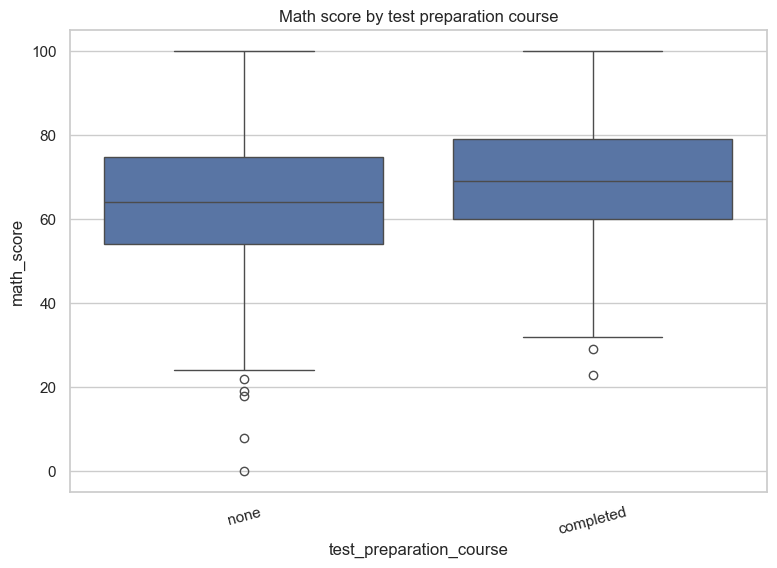

In [8]:
sns.boxplot(data=sp, x="test_preparation_course", y="math_score")
plt.title("Math score by test preparation course")
plt.xticks(rotation=15)
plt.show()

## 6. Корреляции между числовыми признаками
Тепловая карта помогает быстро увидеть, какие score-признаки сильнее связаны между собой.

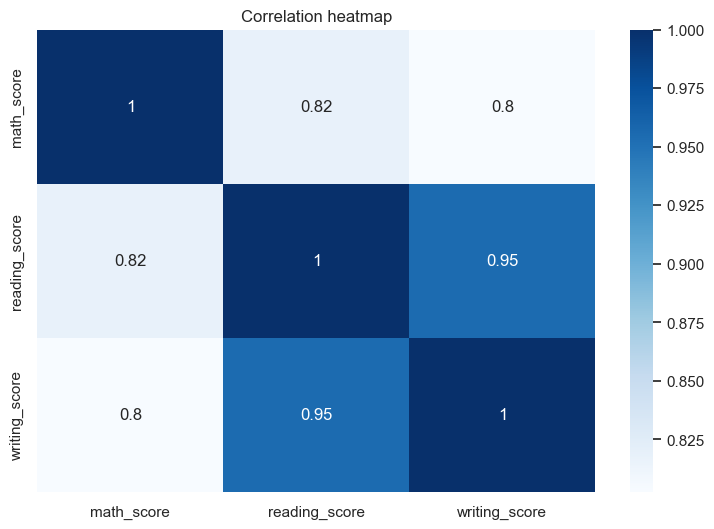

In [9]:
corr = sp[["math_score", "reading_score", "writing_score"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation heatmap")
plt.show()

## Выводы

1. Баллы по трём предметам имеют похожий диапазон, но распределения не полностью совпадают.
2. Между `math_score`, `reading_score` и `writing_score` обычно наблюдается **положительная связь**:
   сильные ученики часто показывают хорошие результаты сразу в нескольких предметах.
3. Визуализация по полу помогает заметить, что группы могут отличаться по профилю успеваемости:
   например, письмо и чтение нередко сильнее у девочек, а математика — у мальчиков.
4. Подготовительный курс выглядит как потенциально полезный фактор: распределение баллов у прошедших курс часто смещено вверх.
5. Даже без сложных моделей графики уже позволяют сформулировать первые гипотезы для дальнейшего анализа.